# Principal Component Analysis (PCA) - Ekdam Detail Mein

## 1. Yeh Kya Hai? (What is PCA?)
Jab hamare paas dataset me bahut saare features (columns) hote hain, toh unme se kuch features aapas me bahut milte-julte (correlated) hote hain. Jaise 'Area in sq ft' aur 'Area in sq meters'. In dono ko rakhne ka koi fayda nahi hai. 

**PCA** ek unsupervised linear dimensionality reduction technique hai. Yeh kya karta hai?
*   Yeh purane features ko milakar naye features banata hai jinhe **Principal Components (PCs)** kehte hain.
*   Yeh naye PCs ek dusre se completely independent (orthogonal) hote hain.
*   **PC1 (First Principal Component):** Yeh wo direction hoti hai jahan data me sabse jyada variance (information/bikhraw) hota hai.
*   **PC2, PC3, etc.:** Uske baad ke PCs orthogonal (90 degrees par) hote hain aur bachi hui variance ko capture karte hain.

*Aasan bhasha me: Yeh 3D cheez ki ek 2D parchai (shadow) lene jaisa hai, aisi angle se jahan us cheez ka shape sabse clear dikhe.*

---

## 2. Hum Ise Kyu Use Karte Hain? (Why use PCA?)
1.  **Dimensionality Reduction:** 1000 features ko 50 features me badalne ke liye bina jyada information lose kiye.
2.  **Visualization:** Hum 30-dimensional data ko toh dekh nahi sakte, par PCA se use 2D ya 3D me convert karke plot kar sakte hain.
3.  **Noise Reduction:** Jo aakhri ke PCs hote hain, unme mostly 'noise' ya bekar data hota hai. Unko drop karne se model clean data par train hota hai.
4.  **Faster Training:** Kam features matlab algorithm jaldi train hoga.

---

## 3. Maths aur Logic Iske Piche (How SVD works in PCA)
Tumhare notes me ek bahut important term hai: **Singular Value Decomposition (SVD)**. Scikit-learn PCA nikalne ke liye SVD ka hi use karta hai. Chalo iski maths samajhte hain.

Maan lo tumhara dataset matrix $X$ hai (jahan mean 0 hai). SVD is matrix ko 3 matrices me tod (decompose) deta hai:
$$ X = U \cdot \Sigma \cdot V^T $$

*   **$U$**: Left singular vectors (Data samples ke bare me info).
*   **$\Sigma$ (Sigma)**: Diagonal matrix. Iske diagonal elements bataate hain ki har PC me kitna "Variance" ya information hai.
*   **$V^T$**: Right singular vectors. Yeh wo **Principal Components** hain! Yeh matrix humein batata hai ki purane features ko kaise combine karke naye PCs banane hain.

**Variance ka Khel:**
Pehle PC ki variance sabse jyada hoti hai, dusre ki usse kam, teesre ki usse kam. Hum utne top $k$ components chunte hain (jaise top 2) jo hamari desired variance (jaise 95%) ko capture kar lein.

---


Original shape of X: (569, 30) (30 Features)

New shape of X after PCA: (569, 10)
Number of components selected to keep 95% variance: 10

Variance captured by each component:
PC1: 44.27%
PC2: 18.97%
PC3: 9.39%
PC4: 6.60%
PC5: 5.50%
Total variance captured: 95.16%


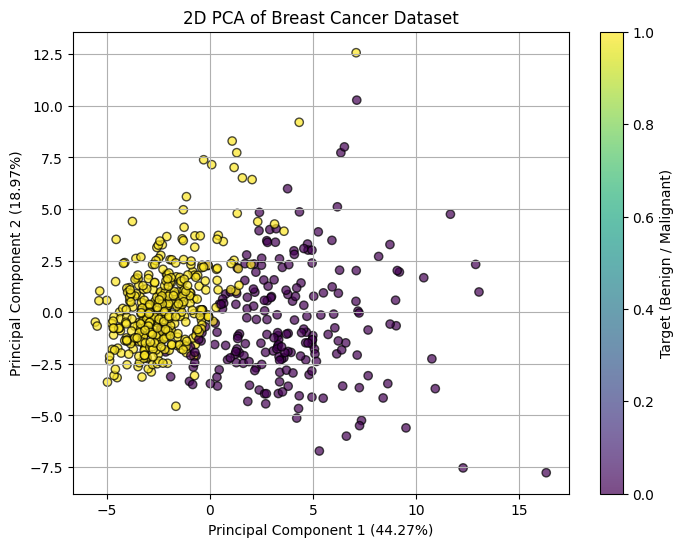

In [1]:
# Implementation Code

# Is code me hum sikhenge ki data ko scale kyu karna zaroori hai, aur hum directly variance percentage de kar kaise decide kar sakte hain ki kitne components chahiye.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load Dataset (Breast Cancer dataset has 30 features)
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(f"Original shape of X: {X.shape} (30 Features)")

# 2. Scaling (VERY IMPORTANT FOR PCA)
# PCA variance par kaam karta hai. Agar ek feature ki value 1000s me hai aur dusre ki 0.1 me, 
# toh PCA confuse ho jayega. Isliye data ko scale karna (mean=0, variance=1) jaruri hai.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA
# Approach A: Humein nahi pata kitne features chahiye, hum bas 95% information (variance) bachana chahte hain.
# Toh hum n_components = 0.95 pass karenge.
pca = PCA(n_components=0.95, random_state=42)

# Fit aur Transform ek sath
X_pca = pca.fit_transform(X_scaled)

print(f"\nNew shape of X after PCA: {X_pca.shape}")
print(f"Number of components selected to keep 95% variance: {pca.n_components_}")

# 4. Under the hood details
# Har PC ne kitni variance capture ki?
variance_ratio = pca.explained_variance_ratio_
print("\nVariance captured by each component:")
for i, var in enumerate(variance_ratio[:5]): # Sirf pehle 5 dikha rahe hain
    print(f"PC{i+1}: {var*100:.2f}%")

print(f"Total variance captured: {np.sum(variance_ratio)*100:.2f}%")

# 5. Visualization (Let's plot the first two components)
# Humein 30D data ko 2D graph par dekhna hai.
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
plt.title('2D PCA of Breast Cancer Dataset')
plt.xlabel(f'Principal Component 1 ({variance_ratio[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({variance_ratio[1]*100:.2f}%)')
plt.colorbar(label='Target (Benign / Malignant)')
plt.grid(True)
plt.show()


## Code Line-by-Line Explanation:
*   **`StandardScaler()`**: PCA karne se pehle yeh step compulsory hai. Yeh ensure karta hai ki sabhi features ka scale ek jaisa ho jaye taaki koi bada number wala feature (jaise Salary) chhote number wale feature (jaise Age) par bhari na pade.
*   **`PCA(n_components=0.95)`**: Yahan tum directly numbers bhi de sakte the (`n_components=2`), par professional approach yeh hoti hai ki tum model ko kaho, "Mujhe itne components de do jisse meri 95% variance (information) bach jaye".
*   **`.fit_transform(X_scaled)`**: Yeh SVD maths chalata hai aur 30 columns ko reduce karke naye columns (hamare case me lagbhag 10 columns) me badal deta hai.
*   **`.explained_variance_ratio_`**: Yeh attribute batata hai ki har ek naye Principal Component me actual data ki kitni percentage information chipi hai. PC1 me humesha sabse jyada hoti hai.
*   **`Visualization Plot`**: Humne 30 columns wale data ko sirf pehle 2 columns (PC1 aur PC2) ke basis par plot kiya. Tum dekhoge ki cancer type (Malignant/Benign) in do components ke graph me bhi kafi hadh tak alag-alag clusters bana raha hai, jiska matlab PCA ne important pattern accurately capture kar liya hai!